# Monte Carlo Random Walk Simulations
--------------------------------------------

## What Is a Random Walk?

Imagine a drunk man leaving a bar at midnight. He's so disoriented that each step
he takes is completely random — 50% chance left, 50% chance right.

**The question:** After 1000 steps, where is he?

This simple question leads to profound physics:
- Diffusion of particles in fluids
- Heat spreading through materials
- Stock price fluctuations
- Even the path of a photon inside the Sun

This unbiased probability can be experienced through the following codes:

## 1. One Drunk Man at One Night - Simpliest Simulation:
----

Let us imagine a drunk man at midnight leaving the bar, he has an unbiased probability of either moving left or right from his position, if we get enough times we can secure a random path that the drunk man might take.


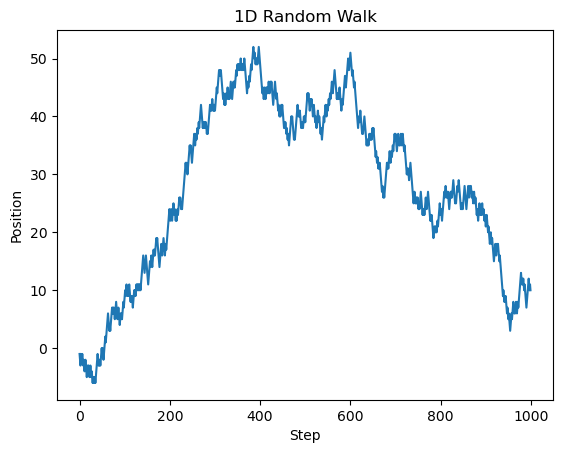

In [1]:
import random
import matplotlib.pyplot as plt

x = 0
loc = []

for i in range(1000):
    if random.random() < 0.5:
        x -= 1
    else:
        x += 1
    loc.append(x)

plt.plot(loc)
plt.xlabel('Step')
plt.ylabel('Position')
plt.title('1D Random Walk')
plt.show()

This walk is of one person and it is unpredictible , sometimes he stays near, sometimes he goes very far, we need multiple statistics to understand it better

## Part 2: Many Drunk Men- Simulation for Multiple People:
---

What if we track 500 drunk men? Each one takes 1000 random steps.
We average their distance from the bar at every step.

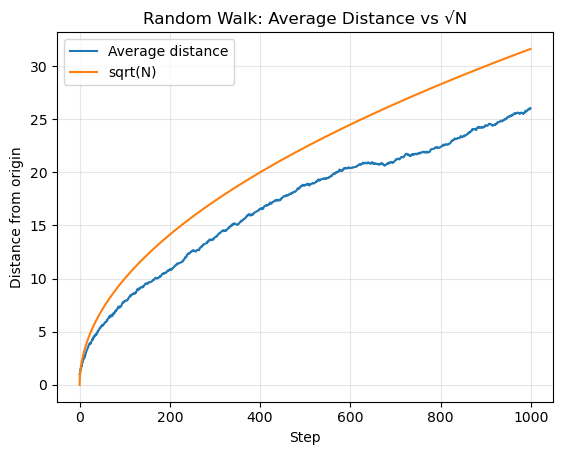

In [2]:
import random
import matplotlib.pyplot as plt
import math

sumdist = [0] * 1000

for j in range(500):
    x = 0
    for i in range(1000):
        x += 1 if random.random() < 0.5 else -1
        sumdist[i] += abs(x)

avg = [d / 500 for d in sumdist]

steps = range(1000)
root_n = [math.sqrt(n) for n in steps]

plt.plot(steps, avg, label='Average distance')
plt.plot(steps, root_n, label='sqrt(N)')
plt.xlabel('Step')
plt.ylabel('Distance from origin')
plt.title('Random Walk: Average Distance vs √N')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**RESULT:** 

Average distance grows as √N. This is the diffusion law —
it governs everything from ink spreading in water to heat flowing through metal.

---

## 3. Biased Drunk Men- Implementing Bias to simulate Real Systems:
---

Real Systems may be controlled by bias, wind pushes particles, trends push stock prices, for here we dream the drunk men steps right 60% of time.

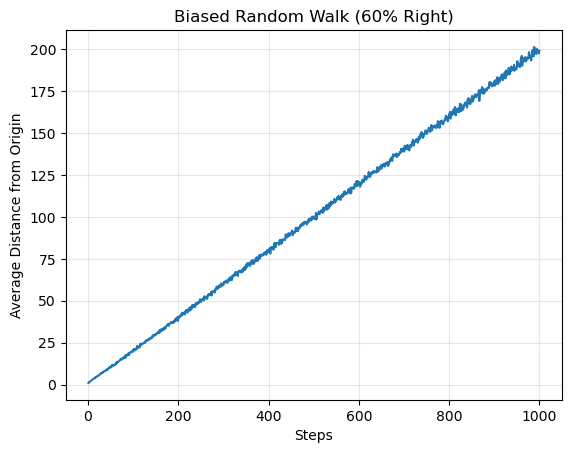

In [6]:
import random
import matplotlib.pyplot as plt

# 500 drunk men, 60% chance to step right
avg_distances = []
for steps in range(1, 1001):
    total_dist = 0
    for j in range(500):
        x = 0
        for i in range(steps):
            x += 1 if random.random() < 0.6 else -1
        total_dist += abs(x)
    avg_distances.append(total_dist / 500)

plt.plot(range(1, 1001), avg_distances)
plt.xlabel('Steps')
plt.ylabel('Average Distance from Origin')
plt.title('Biased Random Walk (60% Right)')
plt.grid(True, alpha=0.3)
plt.show()

**RESULT**

The graph no longer wanders around zero. It **drifts upward** — a clear trend 
emerging from randomness.

## 4. The Ditch Problem:
---
Now let us imagine ditches are present at +10 and -10, and if he falls in any of them the walk ends, we simulate that part and how much the survival gets affected when the ditches get farther and farther apart.

This is used in:
- Ecology (Animals leaving territories)
- Neuroscience (neurons reaching firing thresholds)

Ditch distance +5 and -5: fell 1000/1000, probability = 1.000
Ditch distance +10 and -10: fell 1000/1000, probability = 1.000
Ditch distance +15 and -15: fell 995/1000, probability = 0.995
Ditch distance +20 and -20: fell 954/1000, probability = 0.954
Ditch distance +30 and -30: fell 698/1000, probability = 0.698
Ditch distance +50 and -50: fell 240/1000, probability = 0.240


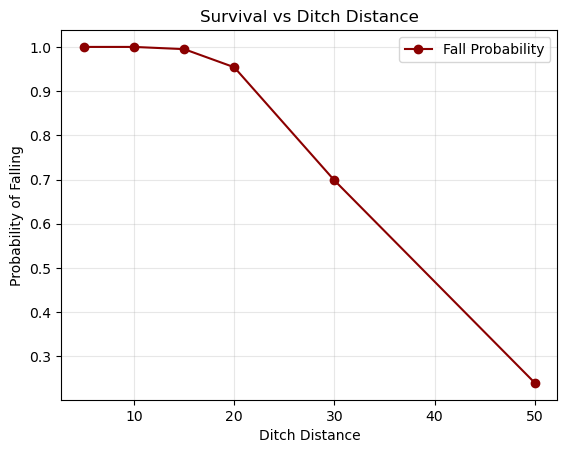

In [8]:
import random
import matplotlib.pyplot as plt

def fall(n):
    x = 0
    for i in range(1000):
        x += 1 if random.random() < 0.5 else -1
        if x == n or x == -n:
            return x, True, i
    return x, False, i

dist = [5, 10, 15, 20, 30, 50]
prob = []

for n in dist:
    left_fall = right_fall = 0
    for _ in range(1000):
        x, fell, i = fall(n)
        if fell:
            if x > 0:
                right_fall += 1
            else:
                left_fall += 1
    
    total_fell = right_fall + left_fall
    probability = total_fell / 1000
    prob.append(probability)
    print(f"Ditch distance +{n} and -{n}: fell {total_fell}/1000, probability = {probability:.3f}")

plt.plot(dist, prob, marker='o', color='darkred', label='Fall Probability')
plt.xlabel('Ditch Distance')
plt.ylabel('Probability of Falling')
plt.title('Survival vs Ditch Distance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**RESULT**
| Ditch Distance | Probability of Falling |
|----------------|------------------------|
| ±5 | 100% — almost instant fall |
| ±10 | ~100% — rarely survives |
| ±15 | ~99% |
| ±20 | ~95% |
| ±30 | ~67% |
| ±50 | ~25% — most walks survive! |

The probability curve drops as ditches get further apart. 
After 1000 steps, the typical distance is √1000 ≈ 31.6. 
Ditches at ±50 are 1.6× further — so most drunk men never reach them.

**What This Models?**

This is the **gambler's ruin** problem — a cornerstone of probability theory.

| Field | Application |
|-------|-------------|
| Ecology | Animals leaving their territory boundaries |
| Neuroscience | Neurons reaching firing threshold |
| Chemistry | Molecules diffusing until they react at a surface |
| Gambling | Player going broke or hitting a win target |

The same math that predicts a drunk man falling into a ditch 
also predicts one's chances of going broke at a casino.

## 5. Conclusion:
---

### What We Built

| Simulation | Monte Carlo Element |
|------------|---------------------|
| Single walk | Random steps |
| 500 walks | Repeated trials → statistics |
| Biased walk | Weighted probabilities |
| Ditch problem | Boundary conditions + probability curves |


All of these simulations share one idea:

> **Use random numbers to solve a problem that is too complex to solve directly.**

We didn't solve equations. We didn't derive formulas. We just:
1. Flipped coins (random numbers)
2. Repeated thousands of times
3. Let patterns emerge from the chaos

### The Name

In the 1940s, scientists at Los Alamos were simulating nuclear reactions. 
Their equations were unsolvable on paper. So they used random sampling — 
letting chance explore every possible outcome.

They named it after the **Monte Carlo Casino** in Monaco. 
Because at its heart, the method is just gambling with physics. 
Roll enough dice, and truth emerges.

---
